In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aklduiawrh/cult-dataset/movies.csv
/kaggle/input/datasets/aklduiawrh/cult-dataset/ratings_full.parquet


In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import sparse
import matplotlib.pyplot as plt
%matplotlib inline

## Configuration

All tunable parameters live here in one place — paths, model
hyperparameters, evaluation settings. If you want to experiment
(fewer factors, different learning rate, smaller subset) this is
the only cell you need to change.

In [6]:
RATINGS_PATH    = "/kaggle/input/datasets/aklduiawrh/cult-dataset/ratings_full.parquet"
MOVIES_PATH     = "/kaggle/input/datasets/aklduiawrh/cult-dataset/movies.csv"
OUT_DIR         = "eda_plots"
TARGET_RATINGS  = 40_000_000
MIN_RATINGS     = 5
TEST_FRAC       = 0.2
N_FACTORS       = 50
LR              = 0.01
REG             = 0.02
EPOCHS          = 25
BATCH_SIZE      = 100_000
PATIENCE        = 3
TOP_K_NEIGHBORS = 100
CF_BLOCK        = 2000
K               = 10
THR             = 4.0
SEED            = 42
os.makedirs(OUT_DIR, exist_ok=True)
print("Config ready. GPU:", "cuda" if torch.cuda.is_available() else "cpu")

Config ready. GPU: cuda


In [7]:
print("Loading data...")
ratings = pd.read_parquet(RATINGS_PATH)
ratings["UserID"]  = ratings["UserID"].astype("int32")
ratings["MovieID"] = ratings["MovieID"].astype("int32")
ratings["Rating"]  = ratings["Rating"].astype("int8")
ratings["Date"]    = pd.to_datetime(ratings["Date"])
movies = pd.read_csv(MOVIES_PATH)
movies["Year"] = movies["Year"].astype("Int64")
print(f"Ratings: {len(ratings):,} | Users: {ratings['UserID'].nunique():,} | "
      f"Movies: {ratings['MovieID'].nunique():,}")

Loading data...
Ratings: 100,480,507 | Users: 480,189 | Movies: 17,770


## Exploratory Data Analysis

Before building any model, we need to understand what the data looks like.
This section explores the Netflix Prize dataset from multiple angles — who
the users are, which movies dominate, how people rate, and how sparse the
data really is. Each plot comes with a business or technical implication
that directly informs our modelling decisions.

**What we look at:**
- User activity — how many movies each user has rated
- Movie popularity — how many ratings each movie received
- Rating distribution — do users rate harshly or generously?
- Rating volume over time — when was Netflix most active?
- Long-tail concentration — do a few movies get all the attention?
- Catalog by release year — how old is the content?

A key number to keep in mind throughout: the user-item matrix is over
**99% sparse**, meaning each user has rated only a tiny fraction of all
available movies. This sparsity is the central challenge every
recommendation model in this project has to solve.

In [17]:
print("Loading data ...")
ratings = pd.read_parquet(RATINGS_PATH)

ratings["UserID"]  = ratings["UserID"].astype("int32")
ratings["MovieID"] = ratings["MovieID"].astype("int32")
ratings["Rating"]  = ratings["Rating"].astype("int8")
ratings["Date"]    = pd.to_datetime(ratings["Date"])

movies = pd.read_csv(MOVIES_PATH)
movies["Year"] = movies["Year"].astype("Int64")

n_ratings = len(ratings)
n_users   = ratings["UserID"].nunique()
n_movies  = ratings["MovieID"].nunique()
density   = n_ratings / (n_users * n_movies)

print(f"\n--- Dataset summary ---")
print(f"Ratings : {n_ratings:,}")
print(f"Users   : {n_users:,}")
print(f"Movies  : {n_movies:,}")
print(f"Density : {density*100:.3f}%  (sparsity {100-density*100:.3f}%)")
print(f"Date range: {ratings['Date'].min().date()} -> {ratings['Date'].max().date()}")

Loading data ...

--- Dataset summary ---
Ratings : 100,480,507
Users   : 480,189
Movies  : 17,770
Density : 1.178%  (sparsity 98.822%)
Date range: 1999-11-11 -> 2005-12-31



Ratings per user -> min 1, median 96, mean 209, max 17,653


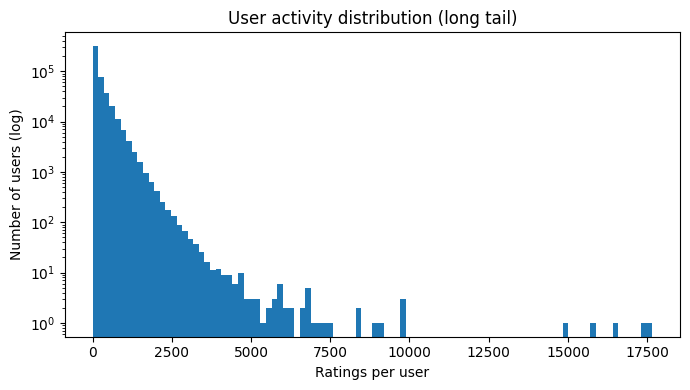

In [18]:
user_counts = ratings.groupby("UserID").size()
print(f"\nRatings per user -> min {user_counts.min()}, "
      f"median {int(user_counts.median())}, mean {user_counts.mean():.0f}, "
      f"max {user_counts.max():,}")

plt.figure(figsize=(7, 4))
plt.hist(user_counts, bins=100, log=True)
plt.xlabel("Ratings per user")
plt.ylabel("Number of users (log)")
plt.title("User activity distribution (long tail)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_user_activity.png", dpi=120)
plt.show()

Rating distribution:
Rating
1     4617990
2    10132080
3    28811247
4    33750958
5    23168232
Name: count, dtype: int64
Global mean rating: 3.604


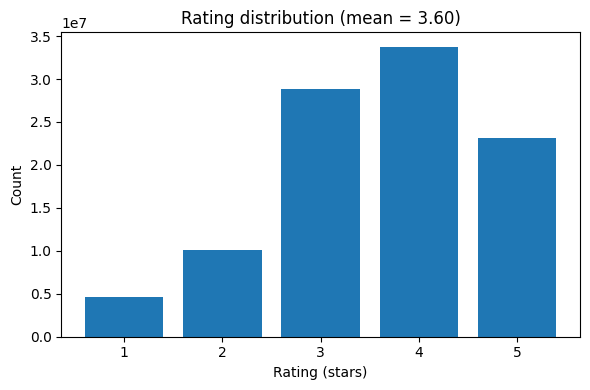

In [19]:
rating_dist = ratings["Rating"].value_counts().sort_index()
print(f"Rating distribution:\n{rating_dist}")
print(f"Global mean rating: {ratings['Rating'].mean():.3f}")

plt.figure(figsize=(6, 4))
plt.bar(rating_dist.index, rating_dist.values)
plt.xlabel("Rating (stars)")
plt.ylabel("Count")
plt.title(f"Rating distribution (mean = {ratings['Rating'].mean():.2f})")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_rating_distribution.png", dpi=120)
plt.show()

Ratings per movie -> min 3, median 561, mean 5655, max 232,944


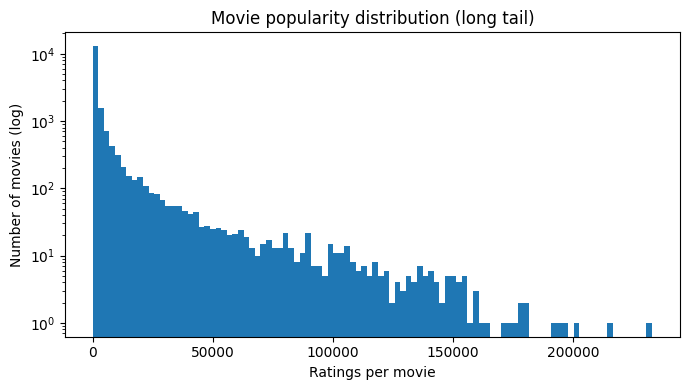

In [20]:
movie_counts = ratings.groupby("MovieID").size()
print(f"Ratings per movie -> min {movie_counts.min()}, "
      f"median {int(movie_counts.median())}, mean {movie_counts.mean():.0f}, "
      f"max {movie_counts.max():,}")

plt.figure(figsize=(7, 4))
plt.hist(movie_counts, bins=100, log=True)
plt.xlabel("Ratings per movie")
plt.ylabel("Number of movies (log)")
plt.title("Movie popularity distribution (long tail)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_movie_popularity.png", dpi=120)
plt.show()

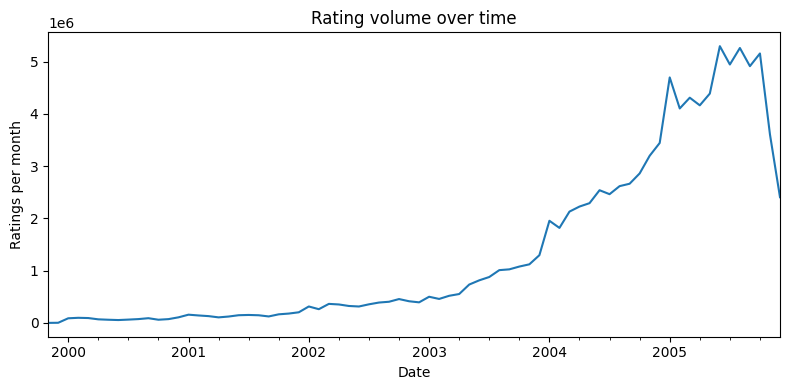

In [21]:
try:
    monthly = ratings.set_index("Date").resample("ME").size()
except ValueError:
    monthly = ratings.set_index("Date").resample("M").size()

plt.figure(figsize=(8, 4))
monthly.plot()
plt.xlabel("Date")
plt.ylabel("Ratings per month")
plt.title("Rating volume over time")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_temporal_trend.png", dpi=120)
plt.show()


Long-tail: top 20% of movies hold 89.2% of all ratings


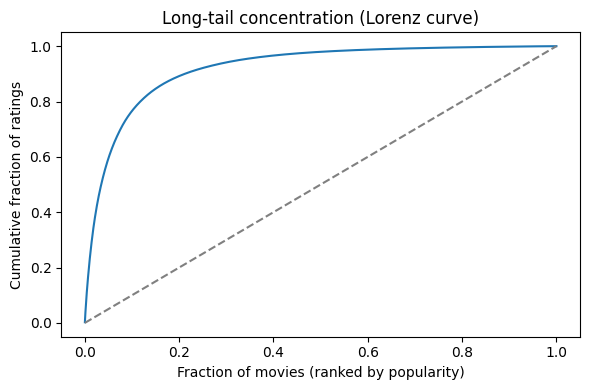

In [22]:
sorted_counts = np.sort(movie_counts.values)[::-1]
cum_share = np.cumsum(sorted_counts) / sorted_counts.sum()
movie_share = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

top20_idx = int(0.20 * len(sorted_counts))
top20_ratings_share = cum_share[top20_idx]
print(f"\nLong-tail: top 20% of movies hold "
      f"{top20_ratings_share*100:.1f}% of all ratings")

plt.figure(figsize=(6, 4))
plt.plot(movie_share, cum_share)
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("Fraction of movies (ranked by popularity)")
plt.ylabel("Cumulative fraction of ratings")
plt.title("Long-tail concentration (Lorenz curve)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_long_tail.png", dpi=120)
plt.show()

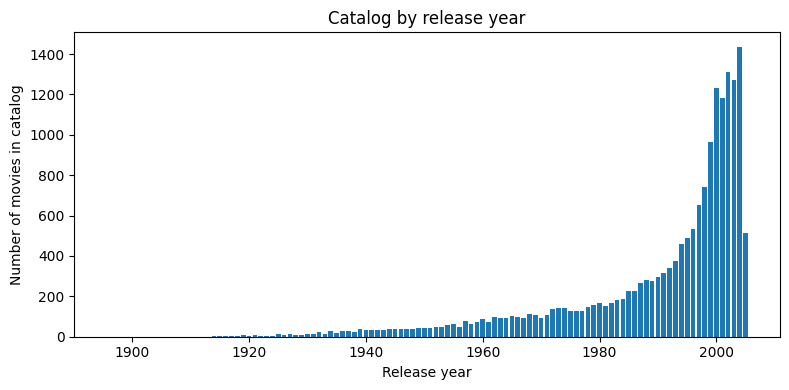


Done. Plots saved in ./eda_plots/

--- Key insights to put in the report ---
* Sparsity is ~98.82% -> CF must rely on co-rated pairs only.
* User activity is heavy-tailed (max 17,653 vs median 96) -> cold/sparse-user handling matters.
* Ratings skew positive (mean 3.60) -> add user/item bias terms; relevance threshold of 3.5 sits just below the mean.
* Top 20% of movies = 89% of ratings -> popularity bias risk; watch recommendation diversity.


In [23]:
year_counts = movies["Year"].dropna().value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(year_counts.index.astype(int), year_counts.values)
plt.xlabel("Release year")
plt.ylabel("Number of movies in catalog")
plt.title("Catalog by release year")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_release_year.png", dpi=120)
plt.show()

print(f"\nDone. Plots saved in ./{OUT_DIR}/")
print("\n--- Key insights to put in the report ---")
print(f"* Sparsity is ~{100-density*100:.2f}% -> CF must rely on co-rated pairs only.")
print(f"* User activity is heavy-tailed (max {user_counts.max():,} vs median "
      f"{int(user_counts.median())}) -> cold/sparse-user handling matters.")
print(f"* Ratings skew positive (mean {ratings['Rating'].mean():.2f}) -> add user/item "
      f"bias terms; relevance threshold of 3.5 sits just below the mean.")
print(f"* Top 20% of movies = {top20_ratings_share*100:.0f}% of ratings -> popularity "
      f"bias risk; watch recommendation diversity.")

## Helper Functions

This cell defines every reusable function the pipeline needs:
subsetting, train/test splitting, baseline predictors, RMSE,
MAP@10, the Funk-SVD model and its training loop, Item-CF
similarity building, prediction, and recommendation generation.

Keeping them all in one cell means restarting the kernel and
re-running this single cell is enough to restore the full environment.

In [8]:
# ── SUBSET ──────────────────────────────────────────────────────────
def build_subset(ratings, target_ratings=40_000_000):
    counts = ratings.groupby("UserID").size().sort_values(ascending=False)
    cumsum = counts.cumsum()
    keep   = cumsum[cumsum <= target_ratings].index
    sub    = ratings[ratings["UserID"].isin(keep)].copy()
    print(f"Subset: {sub['UserID'].nunique():,} users | {len(sub):,} ratings")
    return sub

# ── SPLIT ────────────────────────────────────────────────────────────
def time_based_split(ratings, min_ratings=5, test_frac=0.2):
    df     = ratings.sort_values(["UserID","Date"]).reset_index(drop=True)
    g      = df.groupby("UserID")
    total  = g["Rating"].transform("size").astype("int32")
    rank   = g.cumcount().astype("int32")
    n_test = np.maximum(1, np.floor(test_frac * total)).astype("int32")
    n_test = np.where(total >= min_ratings, n_test, 0)
    is_test = rank >= (total - n_test)
    return df[~is_test].reset_index(drop=True), df[is_test].reset_index(drop=True)

# ── BASELINES ────────────────────────────────────────────────────────
def fit_baselines(train_df):
    mu        = float(train_df["Rating"].mean())
    user_mean = train_df.groupby("UserID")["Rating"].mean()
    item_mean = train_df.groupby("MovieID")["Rating"].mean()
    return mu, user_mean, item_mean

def predict_baseline(df, kind, mu, user_mean, item_mean):
    if kind == "global": return np.full(len(df), mu, dtype="float32")
    if kind == "user":   return df["UserID"].map(user_mean).fillna(mu).to_numpy("float32")
    if kind == "item":   return df["MovieID"].map(item_mean).fillna(mu).to_numpy("float32")

# ── METRICS ──────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true,"float64")
                                  - np.asarray(y_pred,"float64"))**2)))

def average_precision_at_k(actual, predicted, k=10):
    predicted = predicted[:k]; score = 0.0; hits = 0
    for i, movie in enumerate(predicted, start=1):
        if movie in actual:
            hits += 1; score += hits / i
    if len(actual) == 0: return 0.0
    return score / min(len(actual), k)

@torch.no_grad()
def compute_map_at_k_mf(test_df, train_df, model, uid2idx, iid2idx,
                         mu_mf, k=10, thr=4.0, verbose=True):
    idx2iid     = pd.Series(iid2idx.index, index=iid2idx.values)
    rated_train = train_df.groupby("UserID")["MovieID"].agg(set).to_dict()
    rel_test    = test_df[test_df["Rating"]>=thr].groupby("UserID")["MovieID"].agg(set)
    aps = []; n = 0
    for u in [u for u in rel_test.index if u in uid2idx.index]:
        actual = rel_test[u]
        if not actual: continue
        uidx = int(uid2idx[u])
        sc   = (mu_mf + model.bu.weight[uidx].squeeze()
                + model.bi.weight.squeeze(1)
                + model.Q.weight @ model.P.weight[uidx]).cpu().numpy()
        sc[[int(iid2idx[m]) for m in rated_train.get(u,set()) if m in iid2idx.index]] = -np.inf
        ranked = np.argsort(-sc)[:k]
        aps.append(average_precision_at_k(actual, idx2iid.reindex(ranked).dropna().tolist(), k))
        n += 1
    if verbose: print(f"MAP@{k} over {n:,} users (thr={thr})")
    return (float(np.mean(aps)) if aps else 0.0), n

# ── FUNK-SVD ─────────────────────────────────────────────────────────
def build_index_maps(train_df):
    uids = train_df["UserID"].unique(); iids = train_df["MovieID"].unique()
    return (pd.Series(np.arange(len(uids)), index=uids),
            pd.Series(np.arange(len(iids)), index=iids))

def to_tensors(df, uid2idx, iid2idx, device):
    u = df["UserID"].map(uid2idx).to_numpy()
    i = df["MovieID"].map(iid2idx).to_numpy()
    m = ~(pd.isna(u)|pd.isna(i))
    return (torch.tensor(u[m].astype("int64"),device=device),
            torch.tensor(i[m].astype("int64"),device=device),
            torch.tensor(df["Rating"].to_numpy()[m].astype("float32"),device=device))

class FunkSVD(nn.Module):
    def __init__(self, n_users, n_items, n_factors=50, mu=0.0):
        super().__init__()
        self.P=nn.Embedding(n_users,n_factors); self.Q=nn.Embedding(n_items,n_factors)
        self.bu=nn.Embedding(n_users,1);        self.bi=nn.Embedding(n_items,1)
        nn.init.normal_(self.P.weight,std=0.1); nn.init.normal_(self.Q.weight,std=0.1)
        nn.init.zeros_(self.bu.weight);         nn.init.zeros_(self.bi.weight)
        self.register_buffer("mu",torch.tensor(float(mu)))
    def forward(self,u,i):
        return self.mu+self.bu(u).squeeze(1)+self.bi(i).squeeze(1)+(self.P(u)*self.Q(i)).sum(1)
    def reg(self,u,i):
        return (self.P(u).pow(2).sum(1)+self.Q(i).pow(2).sum(1)
                +self.bu(u).squeeze(1).pow(2)+self.bi(i).squeeze(1).pow(2))

def train_funksvd(train_df, n_factors=50, lr=0.01, reg=0.02, epochs=25,
                  batch_size=100_000, val_frac=0.05, patience=3, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    device  = "cuda" if torch.cuda.is_available() else "cpu"
    print("Training Funk-SVD on:", device)
    uid2idx, iid2idx = build_index_maps(train_df)
    mu_mf = float(train_df["Rating"].mean())
    u,i,r = to_tensors(train_df, uid2idx, iid2idx, device)
    perm  = torch.randperm(len(r)); nv = int(val_frac*len(r))
    vi,ti = perm[:nv], perm[nv:]
    uv,iv,rv = u[vi],i[vi],r[vi]; ut,it,rt = u[ti],i[ti],r[ti]
    model = FunkSVD(len(uid2idx),len(iid2idx),n_factors,mu_mf).to(device)
    opt   = torch.optim.Adam(model.parameters(),lr=lr)
    hist,best,best_state,bad = [],[float("inf")],None,0
    for ep in range(epochs):
        model.train(); order=torch.randperm(len(rt),device=device)
        for s in range(0,len(rt),batch_size):
            b=order[s:s+batch_size]; ub,ib,rb=ut[b],it[b],rt[b]
            loss=((model(ub,ib)-rb)**2).mean()+reg*model.reg(ub,ib).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v=torch.sqrt(((model(uv,iv)-rv)**2).mean()).item()
        hist.append(v); print(f"  epoch {ep+1:2d}/{epochs}  val_RMSE={v:.4f}")
        if v < best[0]-1e-4:
            best[0]=v; best_state={k:x.clone() for k,x in model.state_dict().items()}; bad=0
        else:
            bad+=1
            if bad>=patience: print(f"  early stop at epoch {ep+1}"); break
    if best_state: model.load_state_dict(best_state)
    return model, uid2idx, iid2idx, mu_mf, hist

@torch.no_grad()
def mf_predict(df, model, uid2idx, iid2idx, mu_mf):
    device=next(model.parameters()).device
    u=df["UserID"].map(uid2idx).to_numpy(); i=df["MovieID"].map(iid2idx).to_numpy()
    ku=~pd.isna(u); ki=~pd.isna(i)
    us=torch.tensor(np.where(ku,u,0).astype("int64"),device=device)
    is_=torch.tensor(np.where(ki,i,0).astype("int64"),device=device)
    kut=torch.tensor(ku,device=device); kit=torch.tensor(ki,device=device)
    pred=torch.full((len(df),),float(mu_mf),device=device)
    pred+=torch.where(kut,model.bu(us).squeeze(1),torch.zeros_like(pred))
    pred+=torch.where(kit,model.bi(is_).squeeze(1),torch.zeros_like(pred))
    pred+=torch.where(kut&kit,(model.P(us)*model.Q(is_)).sum(1),torch.zeros_like(pred))
    return pred.cpu().numpy()

# ── ITEM-CF ──────────────────────────────────────────────────────────
def build_item_cf(train_df, top_k_neighbors=100, block=2000):
    device  = "cuda" if torch.cuda.is_available() else "cpu"
    print("Building Item-CF on:", device)
    uids=train_df["UserID"].unique(); iids=train_df["MovieID"].unique()
    uid2idx=pd.Series(np.arange(len(uids)),index=uids)
    iid2idx=pd.Series(np.arange(len(iids)),index=iids)
    n_users,n_items=len(uids),len(iids)
    u=train_df["UserID"].map(uid2idx).to_numpy()
    i=train_df["MovieID"].map(iid2idx).to_numpy()
    r=train_df["Rating"].to_numpy("float32")
    user_mean=train_df.groupby("UserID")["Rating"].mean()
    um=user_mean.reindex(uids).to_numpy("float32"); centered=r-um[u]
    M=sparse.csr_matrix((centered,(i,u)),shape=(n_items,n_users))
    norms=np.sqrt(np.asarray(M.multiply(M).sum(axis=1)).ravel())
    inv=1.0/np.where(norms>0,norms,1.0)
    M=M.multiply(inv[:,None]).tocsr().astype("float32")
    Mc=M.tocoo()
    idx=torch.tensor(np.vstack([Mc.row,Mc.col]),dtype=torch.long)
    val=torch.tensor(Mc.data,dtype=torch.float32)
    M_sp=torch.sparse_coo_tensor(idx,val,(n_items,n_users)).coalesce().to(device)
    K=min(top_k_neighbors,n_items-1)
    nbr_idx=np.zeros((n_items,K),dtype="int32"); nbr_sim=np.zeros((n_items,K),dtype="float32")
    for start in range(0,n_items,block):
        end=min(start+block,n_items)
        Mb_T=torch.tensor(M[start:end].toarray().T,dtype=torch.float32,device=device)
        sim=torch.sparse.mm(M_sp,Mb_T).t()
        rows=torch.arange(end-start,device=device)
        sim[rows,torch.arange(start,end,device=device)]=-2.0
        vals,inds=torch.topk(sim,K,dim=1)
        nbr_idx[start:end]=inds.cpu().numpy(); nbr_sim[start:end]=vals.cpu().numpy()
        print(f"  items {end}/{n_items}")
    tr2=train_df[["UserID","MovieID","Rating"]].copy()
    tr2["iidx"]=tr2["MovieID"].map(iid2idx); tr2=tr2.dropna(subset=["iidx"])
    tr2["iidx"]=tr2["iidx"].astype("int64")
    tr2["centered"]=tr2["Rating"]-tr2["UserID"].map(user_mean).to_numpy("float32")
    user_rated={uid:(g["iidx"].to_numpy(),g["centered"].to_numpy("float32"))
                for uid,g in tr2.groupby("UserID")}
    return {"iid2idx":iid2idx,"user_mean":user_mean,"user_rated":user_rated,
            "nbr_idx":nbr_idx,"nbr_sim":nbr_sim,"n_items":n_items}

def predict_item_cf(df, train_df, cf, mu_global):
    iid2idx=cf["iid2idx"]; user_mean=cf["user_mean"]
    nbr_idx=cf["nbr_idx"]; nbr_sim=cf["nbr_sim"]
    n_items=cf["n_items"]; user_rated=cf["user_rated"]
    df=df.reset_index(drop=True)
    te_iidx=df["MovieID"].map(iid2idx).to_numpy()
    pred=np.full(len(df),mu_global,dtype="float32")
    vec=np.zeros(n_items,dtype="float32"); msk=np.zeros(n_items,dtype=bool)
    for uid,g in df.groupby("UserID"):
        mu_u=float(user_mean.get(uid,mu_global)); pos=g.index.to_numpy()
        rated=user_rated.get(uid)
        if rated is None: pred[pos]=mu_u; continue
        ridx,rcent=rated; vec[ridx]=rcent; msk[ridx]=True
        tiidx=te_iidx[pos]
        for k,p in enumerate(pos):
            ti=tiidx[k]
            if np.isnan(ti): pred[p]=mu_u; continue
            ti=int(ti); j=nbr_idx[ti]; s=nbr_sim[ti]
            ok=msk[j]&(s>0); den=np.abs(s[ok]).sum()
            pred[p]=mu_u+(s[ok]*vec[j[ok]]).sum()/den if den>0 else mu_u
        vec[ridx]=0.0; msk[ridx]=False
    return np.clip(pred,1.0,5.0)

# ── RECOMMENDATIONS ──────────────────────────────────────────────────
@torch.no_grad()
def generate_recommendations(user_id, model, uid2idx, iid2idx,
                              mu_mf, train_df, movies, K=10):
    if user_id not in uid2idx.index: return None
    device=next(model.parameters()).device
    rated=set(train_df[train_df["UserID"]==user_id]["MovieID"].tolist())
    uidx=int(uid2idx[user_id])
    pu=model.P.weight[uidx]; bu=model.bu.weight[uidx].squeeze()
    scores=(mu_mf+bu+model.bi.weight.squeeze(1)+model.Q.weight@pu).cpu().numpy()
    scores[[int(iid2idx[m]) for m in rated if m in iid2idx.index]]=-np.inf
    ranked=np.argsort(-scores)[:K]
    idx2iid=pd.Series(iid2idx.index,index=iid2idx.values)
    top_mids=idx2iid.reindex(ranked).to_numpy()
    return pd.DataFrame({
        "Rank":np.arange(1,K+1),"MovieID":top_mids,
        "Title":movies.set_index("MovieID")["Title"].reindex(top_mids).to_numpy(),
        "Year":movies.set_index("MovieID")["Year"].reindex(top_mids).to_numpy(),
        "PredScore":np.round(np.clip(scores[ranked],1.0,5.0),3)})

def user_profile(user_id, train_df, movies, n=8):
    h=train_df[train_df["UserID"]==user_id].merge(movies,on="MovieID")
    return h.sort_values("Rating",ascending=False)[["Title","Year","Rating"]].head(n).reset_index(drop=True)

def show_user_recommendations(user_id, model, uid2idx, iid2idx, mu_mf,
                              train_df, test_df, movies, K=10, thr=4.0):
    recs=generate_recommendations(user_id,model,uid2idx,iid2idx,mu_mf,train_df,movies,K)
    if recs is None: return None
    ut=test_df[test_df["UserID"]==user_id].set_index("MovieID")["Rating"]
    recs=recs.copy()
    recs["Outcome"]=[("HIT (>=4)" if ut.get(m,0)>=thr else "miss (<4)")
                      if m in ut.index else "not in test" for m in recs["MovieID"]]
    return recs

print("All functions loaded.")

All functions loaded.


## Subset and Train / Test Split

The full dataset has 100 million ratings which is too large to
train efficiently. We keep the most active users — they have the
richest interaction history, so models learn better patterns from
them. We target 40 million ratings.

The split is **time-based per user**: each user's most recent 20%
of ratings become the test set, and the earlier 80% form the
training set. This mimics the real-world scenario of predicting
future preferences from past behaviour, with no data leakage.

In [10]:
sub = build_subset(ratings, TARGET_RATINGS)

Subset: 41,335 users | 39,999,477 ratings


In [11]:
train_df, test_df = time_based_split(sub, MIN_RATINGS, TEST_FRAC)

In [12]:
# ── Subset + split
mu, user_mean, item_mean = fit_baselines(train_df)
mu0 = mu
print(f"Global mean: {mu:.3f}")

Global mean: 3.497


## Training the Primary Model — Funk-SVD (Matrix Factorization)

**Make sure the GPU accelerator is ON before running this cell.**
In Kaggle: Settings → Accelerator → GPU T4 x2.
The first printed line should say `Training Funk-SVD on: cuda`.
If it says `cpu`, stop and enable the GPU first.

Funk-SVD is our main model. It represents every user and every movie
as a short vector of hidden factors, and learns these vectors by
minimising prediction error on the training ratings. The formula is:

**r̂(u,i) = μ + b_u + b_i + p_u · q_i**

where μ is the global mean, b_u and b_i are user and item bias terms,
and p_u · q_i is the dot product of the latent factor vectors.
Training uses mini-batch Adam with early stopping on validation RMSE.

In [13]:
# ── Train Funk-SVD  (GPU cell — make sure accelerator is ON)
model, uid2idx, iid2idx, mu_mf, history = train_funksvd(
    train_df, N_FACTORS, LR, REG, EPOCHS, BATCH_SIZE, patience=PATIENCE, seed=SEED)

Training Funk-SVD on: cuda
  epoch  1/25  val_RMSE=0.8210
  epoch  2/25  val_RMSE=0.8019
  epoch  3/25  val_RMSE=0.7958
  epoch  4/25  val_RMSE=0.7934
  epoch  5/25  val_RMSE=0.7920
  epoch  6/25  val_RMSE=0.7915
  epoch  7/25  val_RMSE=0.7910
  epoch  8/25  val_RMSE=0.7906
  epoch  9/25  val_RMSE=0.7905
  epoch 10/25  val_RMSE=0.7901
  epoch 11/25  val_RMSE=0.7901
  epoch 12/25  val_RMSE=0.7897
  epoch 13/25  val_RMSE=0.7898
  epoch 14/25  val_RMSE=0.7898
  epoch 15/25  val_RMSE=0.7897
  early stop at epoch 15


## Building the Comparison Model — Item-Based Collaborative Filtering

Item-CF is our second model, included so we can make the required
comparison between at least two approaches.

For every pair of movies it computes how similarly users rated them
(adjusted cosine similarity — ratings are centred by user mean before
comparing). We store only the top-100 most similar neighbours per movie
to keep memory manageable. The GPU handles the large matrix multiply
that makes this practical in minutes rather than hours.

In [14]:
# ── Build Item-CF
cf = build_item_cf(train_df, TOP_K_NEIGHBORS, CF_BLOCK)

Building Item-CF on: cuda
  items 2000/17749
  items 4000/17749
  items 6000/17749
  items 8000/17749
  items 10000/17749
  items 12000/17749
  items 14000/17749
  items 16000/17749
  items 17749/17749


## Evaluation — RMSE and MAP@10

We evaluate every model on the same held-out test set using two metrics:

- **RMSE** (Root Mean Squared Error) — measures how accurately the model
  predicts the numeric star rating. Lower is better.

- **MAP@10** (Mean Average Precision at 10) — measures ranking quality.
  For each user we rank all unseen movies by predicted score, take the
  top 10, and check how many of the movies they genuinely liked
  (rated ≥ 4) appear there and how highly ranked they are.
  Higher is better.

A movie is considered **relevant** if its actual rating is ≥ 4.
The two metrics capture different things — a model can have good RMSE
but poor MAP@10 if it predicts scores accurately but ranks the wrong
movies at the top.

In [15]:
# ── Evaluate all models
results = []
for kind in ["global", "user", "item"]:
    test_df["pred"] = predict_baseline(test_df, kind, mu, user_mean, item_mean)
    results.append({"Model": f"{kind}-mean",
                    "RMSE": round(rmse(test_df["Rating"], test_df["pred"]), 4),
                    "MAP@10": "N/A"})

# Funk-SVD
test_df["pred"] = mf_predict(test_df, model, uid2idx, iid2idx, mu_mf)
mf_rmse = rmse(test_df["Rating"], test_df["pred"])
mf_map, _ = compute_map_at_k_mf(test_df, train_df, model,
                                  uid2idx, iid2idx, mu_mf, K, THR)
results.append({"Model": "Funk-SVD", "RMSE": round(mf_rmse,4),
                "MAP@10": round(mf_map,4)})

# Item-CF
test_df["pred"] = predict_item_cf(test_df, train_df, cf, mu)
cf_rmse = rmse(test_df["Rating"], test_df["pred"])
results.append({"Model": "Item-CF", "RMSE": round(cf_rmse,4), "MAP@10": "N/A"})

final = pd.DataFrame(results)
print(final.to_string(index=False))

MAP@10 over 41,325 users (thr=4.0)
      Model   RMSE  MAP@10
global-mean 1.0540     N/A
  user-mean 0.9810     N/A
  item-mean 0.9825     N/A
   Funk-SVD 0.8151  0.0153
    Item-CF 0.8809     N/A


## Recommendation Examples — Seeing the Pipeline in Action

Numbers tell us which model wins. Actual movie titles tell us whether
the recommendations make sense. We pick a sample user, show their
taste profile (their highest-rated movies in training), and then show
the top-10 movies the model recommends for them.

Each recommendation is labelled:
- **HIT (≥4)** — the user rated this in the test set and loved it 
- **miss (<4)** — they rated it but were not impressed 
- **not in test** — they did not rate it in the held-out period, so we
  cannot verify it either way

Most recommendations will say "not in test" — that is expected and
honest. We rank all ~17,000 unseen movies, but each user only rated
a handful during the test window. The HITs are what prove the model
is surfacing movies the user genuinely enjoys.

In [16]:
# ── Sample recommendations
sample_user = train_df["UserID"].value_counts().index[0]
print(f"Profile for user {sample_user}:")
print(user_profile(sample_user, train_df, movies, n=5).to_string(index=False))
print(f"\nTop-10 recommendations:")
print(show_user_recommendations(sample_user, model, uid2idx, iid2idx,
                                 mu_mf, train_df, test_df, movies,
                                 K=10, thr=THR).to_string(index=False))

Profile for user 305344:
                                                                 Title  Year  Rating
                              Suze Orman: 9 Steps to Financial Freedom  1998       5
                           Rick Springfield: The Beat of the Live Drum  1985       5
The John Wayne Collection: Vol. 2: Riders of Destiny / The Star Packer  1934       5
                                         Fleetwood Mac: Live in Boston  2004       5
                                        Suze Orman: The Road to Wealth  2001       5

Top-10 recommendations:
 Rank  MovieID                               Title  Year  PredScore     Outcome
    1    10784                 Elf: Bonus Material  2003      4.910 not in test
    2    12737                       In Cold Blood  1996      4.554   miss (<4)
    3    17186      The Private Life of Henry VIII  1932      4.405   miss (<4)
    4    11564                  Over There (Pilot)  2005      4.226   miss (<4)
    5    14093          Best of the Blue